In [1]:
import os
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import json
from tqdm.auto import tqdm

In [2]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# Dataset and Dataloader


In [3]:
root_data_dir= '/kaggle/input/datasets/sharadprakash117/lung-tumour-baseline-u-net-seg-dataset-filtered/npy_filtered' 
train_dir= root_data_dir+'/train'
val_dir= root_data_dir+'/val'
test_dir= root_data_dir+'/test'

In [4]:

class NpyLesionDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.file_pairs = []
        
        # Traverse the filtered directory
        for dir_name in os.listdir(root_dir):
            data_dir = os.path.join(root_dir, dir_name, 'data')
            masks_dir = os.path.join(root_dir, dir_name, 'masks')
            
            if not os.path.isdir(data_dir): continue
                
            for fname in os.listdir(data_dir):
                if fname.endswith('.npy'):
                    self.file_pairs.append({
                        'image': os.path.join(data_dir, fname),
                        'mask': os.path.join(masks_dir, fname)
                    })

    def __len__(self):
        return len(self.file_pairs)

    def __getitem__(self, idx):
        pair = self.file_pairs[idx]
        
        # Load normalized arrays
        img = np.load(pair['image']).astype(np.float32)
        mask = np.load(pair['mask']).astype(np.float32)
        
        # Ensure masks are strictly binary (0 or 1)
        mask = (mask > 0).astype(np.float32)
        
        # Add channel dimension: (H, W) -> (1, H, W)
        img = np.expand_dims(img, axis=0)
        mask = np.expand_dims(mask, axis=0)
        
        return torch.from_numpy(img), torch.from_numpy(mask)

In [5]:
train_dataset=NpyLesionDataset(train_dir)
train_loader=DataLoader(train_dataset,batch_size=16,shuffle=True)

In [6]:
val_dataset=NpyLesionDataset(val_dir)
val_loader=DataLoader(val_dataset,batch_size=16,shuffle=False)

In [7]:
test_dataset=NpyLesionDataset(test_dir)
test_loader=DataLoader(test_dataset,batch_size=16,shuffle=False)

In [8]:
batch=next(iter(val_loader))

In [9]:
print(f"Batch size: {len(batch)}")

Batch size: 2


torch.Size([1, 256, 256])


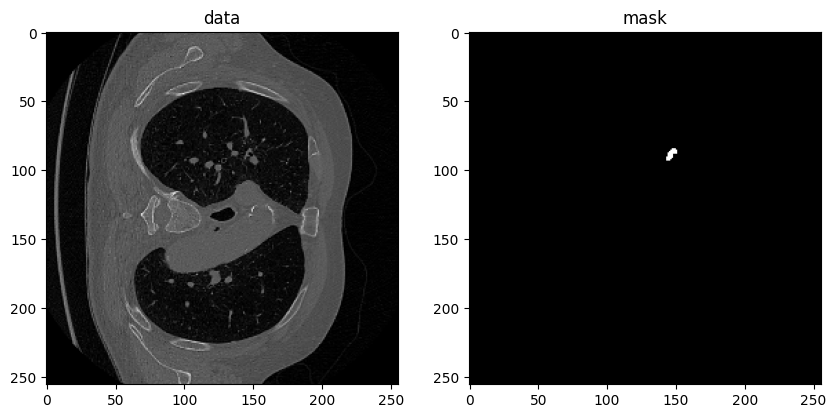

In [10]:
print(batch[0][5].shape)  # Images
img=batch[0][2].squeeze().numpy()
mask=batch[1][2].squeeze().numpy()
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("data")
plt.imshow(img,cmap='gray') 
plt.subplot(1,2,2)
plt.title("mask")
plt.imshow(mask,cmap='gray')
plt.show()

# model arch

In [11]:
import torch
import torch.nn as nn

class BCEDiceLoss(nn.Module):
    def __init__(self, alpha=0.5, smooth=1e-6):
        super(BCEDiceLoss, self).__init__()
        self.alpha = alpha
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, preds, targets):
        # BCE Loss
        bce_loss = self.bce(preds, targets)
        
        # Dice Loss
        preds = torch.sigmoid(preds)
        preds = preds.view(-1)
        targets = targets.view(-1)
        
        intersection = (preds * targets).sum()
        dice_coeff = (2. * intersection + self.smooth) / (preds.sum() + targets.sum() + self.smooth)
        dice_loss = 1 - dice_coeff
        
        return self.alpha * bce_loss + (1 - self.alpha) * dice_loss
    

In [12]:
class DoubleConv(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class UNetBaseline(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        # Encoder
        self.inc = DoubleConv(in_channels, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))
        
        # Decoder
        self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv_up1 = DoubleConv(512, 256) # 512 because of skip connection concatenation
        
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv_up2 = DoubleConv(256, 128)
        
        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv_up3 = DoubleConv(128, 64)
        
        # Final Task Head
        self.outc = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # Down
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        
        # Up (with skip connections)
        x = self.up1(x4)
        x = torch.cat([x3, x], dim=1)
        x = self.conv_up1(x)
        
        x = self.up2(x)
        x = torch.cat([x2, x], dim=1)
        x = self.conv_up2(x)
        
        x = self.up3(x)
        x = torch.cat([x1, x], dim=1)
        x = self.conv_up3(x)
        
        logits = self.outc(x)
        return logits

In [14]:
def get_detailed_metrics(preds, targets, threshold=0.5, smooth=1e-6):
    preds = (torch.sigmoid(preds) > threshold).float()
    targets = targets.float()

    # Determine if there is a tumor in the ground truth
    has_tumor = (targets.sum() > 0)
    
    # Flatten for pixel calculations
    preds_f = preds.view(-1)
    targets_f = targets.view(-1)

    intersection = (preds_f * targets_f).sum()
    dice = (2. * intersection + smooth) / (preds_f.sum() + targets_f.sum() + smooth)
    iou = (intersection + smooth) / (preds_f.sum() + targets_f.sum() - intersection + smooth)

    # Calculate Sensitivity (Recall) for this slice
    # If no tumor exists, recall isn't applicable for the 'lesion' class
    recall = intersection / (targets_f.sum() + smooth) if has_tumor else None

    return {
        'dice': dice.item(),
        'iou': iou.item(),
        'recall': recall.item() if recall is not None else None,
        'is_positive': has_tumor.item()
    }

In [13]:
model=UNetBaseline().to(device)
print(model)

UNetBaseline(
  (inc): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Sequential(
    (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (1): DoubleConv(
      (double_conv): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(128, eps

In [15]:
def train_and_validate(model, train_loader, val_loader, num_epochs=20):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    
    criterion = BCEDiceLoss(alpha=0.5)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    
    history = {
        'train_loss': [], 'val_loss': [],
        'train_dice': [],
        'val_dice_all': [], 'val_dice_pos': [],  # Overall vs Tumor-only
        'val_iou_all': [], 'val_recall_pos': []   # Spatial overlap vs Positive Recall
    }

    for epoch in range(num_epochs):
        # --- TRAINING PHASE ---
        model.train()
        t_loss, t_dice_all = 0, 0
        
        for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]"):
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            
            t_loss += loss.item()
            
            # Fast, overall Dice for progress monitoring
            with torch.no_grad():
                # Just get the 'all' metric to avoid slow looping during training
                m_fast = get_detailed_metrics(outputs, masks) # Modified to handle batches
                t_dice_all += m_fast['dice']

        history['train_dice'].append(t_dice_all / len(train_loader))

        # --- VALIDATION ---
        model.eval()
        v_loss = 0
        v_d_all, v_d_pos, v_iou, v_rec = [], [], [], []
        
        with torch.no_grad():
            for images, masks in tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]"):
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)
                v_loss += criterion(outputs, masks).item()
                
                # Metric calculation per slice in batch
                for i in range(images.size(0)):
                    m = get_detailed_metrics(outputs[i], masks[i])
                    v_d_all.append(m['dice'])
                    v_iou.append(m['iou'])
                    if m['is_positive']:
                        v_d_pos.append(m['dice'])
                        v_rec.append(m['recall'])

        # Store Averages
        history['train_loss'].append(t_loss / len(train_loader))
        history['val_loss'].append(v_loss / len(val_loader))
        history['val_dice_all'].append(np.mean(v_d_all))
        history['val_iou_all'].append(np.mean(v_iou))
        history['val_dice_pos'].append(np.mean(v_d_pos) if v_d_pos else 0)
        history['val_recall_pos'].append(np.mean(v_rec) if v_rec else 0)

        print(f"Epoch {epoch+1} | Val Dice (All): {history['val_dice_all'][-1]:.4f} | "
              f"Dice (Pos): {history['val_dice_pos'][-1]:.4f} | Recall: {history['val_recall_pos'][-1]:.4f}")

    with open('baseline_history.json', 'w') as f:
        json.dump(history, f)
    torch.save(model.state_dict(), 'baseline_unet.pth')
    
    return history

In [16]:
history=train_and_validate(model, train_loader, val_loader, num_epochs=20)

Epoch 1 [Train]:   0%|          | 0/180 [00:00<?, ?it/s]

Epoch 1 [Val]:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1 | Val Dice (All): 0.4527 | Dice (Pos): 0.0000 | Recall: 0.0000


Epoch 2 [Train]:   0%|          | 0/180 [00:00<?, ?it/s]

Epoch 2 [Val]:   0%|          | 0/10 [00:00<?, ?it/s]

...

Epoch 19 [Val]:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 19 | Val Dice (All): 0.6543 | Dice (Pos): 0.3898 | Recall: 0.3535


Epoch 20 [Train]:   0%|          | 0/180 [00:00<?, ?it/s]

Epoch 20 [Val]:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 20 | Val Dice (All): 0.6442 | Dice (Pos): 0.4101 | Recall: 0.3792


In [ ]:
print(history)

{'train_loss': [0.6494121193885803, 0.5932722243997786, 0.55723757147789, 0.5245954743689961, 0.4953205946418974, 0.4654317003157404, 0.42577560626798205, 0.36583838446272743, 0.2842345020009412, 0.20477519912852182, 0.16198960774474674, 0.1202626583683822, 0.1010372342955735, 0.0907704380237394, 0.0789409391892453, 0.07928970815199944, 0.07034736739264594, 0.09729248532611463, 0.05811854975505008, 0.055531259739978446], 'val_loss': [0.6185848236083984, 0.5819677948951721, 0.5466264486312866, 0.527035516500473, 0.507687246799469, 0.49513663351535797, 0.4679248988628387, 0.40623652637004853, 0.36831137388944624, 0.34284004271030427, 0.2848863065242767, 0.2549988582730293, 0.22451598867774009, 0.20542349219322203, 0.235993330180645, 0.2245684675872326, 0.2177003301680088, 0.27687900215387345, 0.2530601888895035, 0.23667404502630235], 'train_dice': [0.0013743372266193286, 0.029350359402762052, 0.4159495070865877, 0.5791887403415037, 0.6521072643084659, 0.6681837692053324, 0.70026075341221

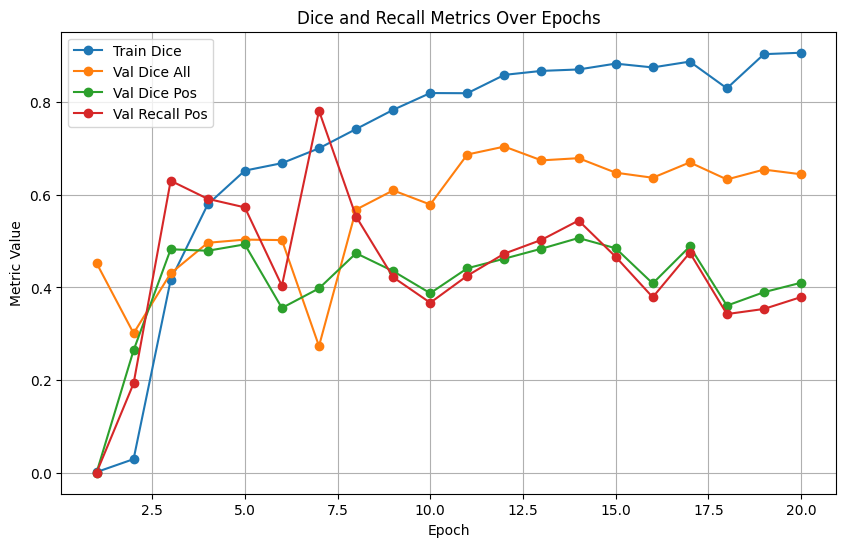

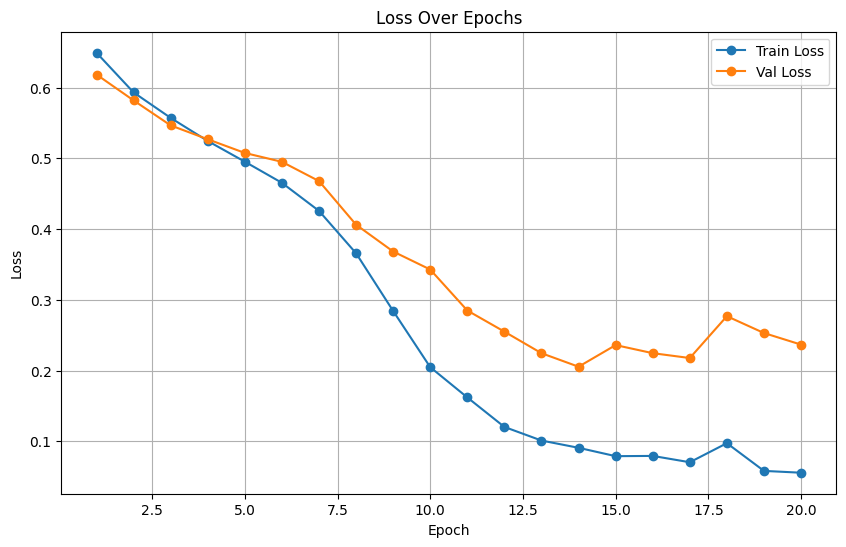

In [18]:
# Add this cell after the training cell to plot the history

import matplotlib.pyplot as plt

# Assuming history is already defined from the training function
epochs = range(1, len(history['train_loss']) + 1)

# Plot 1: Dice and Recall metrics
plt.figure(figsize=(10, 6))
plt.plot(epochs, history['train_dice'], label='Train Dice', marker='o')
plt.plot(epochs, history['val_dice_all'], label='Val Dice All', marker='o')
plt.plot(epochs, history['val_dice_pos'], label='Val Dice Pos', marker='o')
plt.plot(epochs, history['val_recall_pos'], label='Val Recall Pos', marker='o')
plt.title('Dice and Recall Metrics Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Metric Value')
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: Loss metrics
plt.figure(figsize=(10, 6))
plt.plot(epochs, history['train_loss'], label='Train Loss', marker='o')
plt.plot(epochs, history['val_loss'], label='Val Loss', marker='o')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [28]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

def evaluate_and_visualize_test(model, test_loader, save_path):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    model.eval()
    os.makedirs(save_path, exist_ok=True)

    # Accumulators for Global (Joint) Metrics
    total_inter = 0
    total_mask_pix = 0
    total_pred_pix = 0
    
    # Counters for Positive Recall (Sensitivity)
    total_pos_slices = 0
    detected_pos_slices = 0
    
    smooth = 1e-6

    with torch.no_grad():
        for i, (images, masks) in enumerate(tqdm(test_loader, desc="Testing & Visualizing")):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            preds = (torch.sigmoid(outputs) > 0.5).float()

            # --- 1. Update Global Metric Data ---
            preds_f = preds.view(-1)
            masks_f = masks.view(-1)

            total_inter += (preds_f * masks_f).sum().item()
            total_mask_pix += masks_f.sum().item()
            total_pred_pix += preds_f.sum().item()

            # --- 2. Process Batch for Individual Visualization & Recall ---
            for b in range(images.size(0)):
                img_np = images[b, 0].cpu().numpy()
                gt_np = masks[b, 0].cpu().numpy()
                pred_np = preds[b, 0].cpu().numpy()

                has_gt = gt_np.max() > 0
                has_pred = pred_np.max() > 0

                # Calculate specific metrics for THIS slice visualization
                inter_s = (pred_np * gt_np).sum()
                union_s = pred_np.sum() + gt_np.sum() - inter_s
                dice_s = (2. * inter_s + smooth) / (pred_np.sum() + gt_np.sum() + smooth)
                iou_s = (inter_s + smooth) / (union_s + smooth)

                if has_gt:
                    total_pos_slices += 1
                    if inter_s > 0:
                        detected_pos_slices += 1

                # --- 3. Save Visualization ---
                if has_gt or has_pred:
                    fig, ax = plt.subplots(1, 2, figsize=(14, 7))
                    
                    # Original CT
                    ax[0].imshow(img_np, cmap='gray')
                    ax[0].set_title("Original CT Scan")
                    ax[0].axis('off')
                    
                    # Overlay: Green = GT, Red = Pred, Yellow = Overlap
                    overlay = np.stack([img_np]*3, axis=-1) 
                    overlay[gt_np > 0] = [0, 1, 0]   # GT in Green
                    overlay[pred_np > 0] = [1, 0, 0] # Pred in Red
                    
                    ax[1].imshow(overlay)
                    # Putting metrics on top for easy identification
                    ax[1].set_title(f"GT: Green | Pred: Red\nDice: {dice_s:.4f} | IoU: {iou_s:.4f}")
                    ax[1].axis('off')
                    
                    plt.tight_layout()
                    plt.savefig(os.path.join(save_path, f"result_b{i}_s{b}.png"), dpi=150)
                    plt.close()

    # --- 4. Final Global Calculations ---
    global_dice = (2. * total_inter + smooth) / (total_mask_pix + total_pred_pix + smooth)
    global_iou = (total_inter + smooth) / (total_mask_pix + total_pred_pix - total_inter + smooth)
    recall_rate = detected_pos_slices / (total_pos_slices + smooth)

    metrics = {
        "global_dice": global_dice,
        "global_iou": global_iou,
        "recall_rate": recall_rate,
        "total_tumor_slices": total_pos_slices,
        "detected_tumor_slices": detected_pos_slices
    }

    print(f"\nGlobal Dice: {global_dice:.4f} | Global IoU: {global_iou:.4f}")
    print(f"Recall: {recall_rate:.4f} ({detected_pos_slices}/{total_pos_slices})")
    
    return metrics

In [29]:
model=UNetBaseline().to(device)
model.load_state_dict(torch.load('baseline_unet.pth', map_location=device))
model.eval()

UNetBaseline(
  (inc): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Sequential(
    (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (1): DoubleConv(
      (double_conv): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(128, eps

In [30]:

test_stats=evaluate_and_visualize_test(model,test_loader,'/kaggle/working/baseline_test_set_outputs')

Testing & Visualizing: 100%|██████████| 84/84 [01:33<00:00,  1.12s/it]


Global Dice: 0.4436 | Global IoU: 0.2850
Recall: 0.5842 (59/101)
